# Provenance of model 31's fixed width scaling (δ_σ ≈ 1.29)

Sweeps models 115–135, which fix the width-scaling ratio r_σ = model_label / 100 (i.e., 1.15–1.35), and plots cross-validated R², in-sample R², and log-likelihood as a function of r_σ (NPCr voxels, all subjects, with and without `fit_responses`).

The likelihood-maximizing value, r_σ ≈ 1.2878 ≈ 1.29, is the value fixed in model 31, the primary production model (paper section "Efficient shifts, fixed width-scaling").

In [68]:
from neural_priors.utils.data import Subject, get_all_subject_ids
from tqdm.contrib.itertools import product
import pandas as pd
import seaborn as sns

In [69]:
subject_id = 1
model = 115


df = []

for subject_id, model, fit_responses in product(get_all_subject_ids(), list(range(115, 136)), [True, False]):
    try:
        sub = Subject(subject_id)
        d = sub.get_prf_parameters_volume(roi='NPCr', model_label=model, use_nifti=False, response_fit=fit_responses)
        d.index.name = 'voxel'
        d['subject'], d['model_label'] = subject_id, model
        d['fit_responses'] = fit_responses
        d.set_index(['subject', 'model_label', 'fit_responses'], append=True, inplace=True)
        d.index.reorder_levels(['subject', 'model_label', 'fit_responses', 'voxel'])
        df.append(d)
    except Exception as e:
        print(f"Error processing subject {subject_id} and model {model}: {e}")

df = pd.concat(df)

  0%|          | 0/1638 [00:00<?, ?it/s]

In [92]:
df = df.set_index(pd.Index(df.index.get_level_values('model_label').map(lambda x: x/100.), name='sd_scale'), append=True)

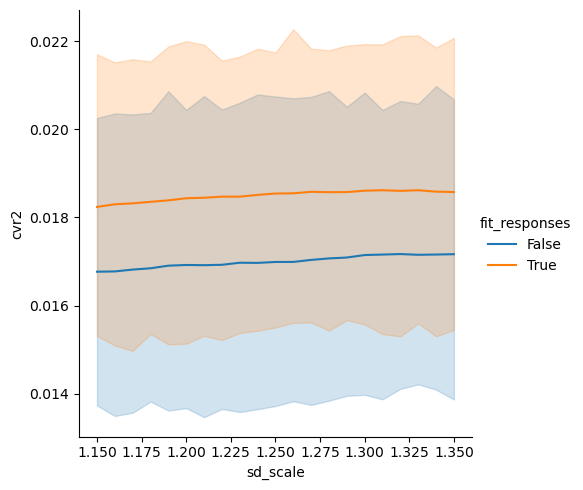

In [95]:
cvr2 = df[('cvr2', 'nan')]
tmp = cvr2.unstack('model_label')

tmp = tmp[(tmp > 0).any(axis=1)]

tmp = tmp.stack().to_frame('cvr2')

sns.relplot(data=tmp.groupby(level=['subject', 'model_label', 'fit_responses', 'sd_scale']).mean().reset_index(), x='sd_scale', y='cvr2', kind='line',
            hue='fit_responses')

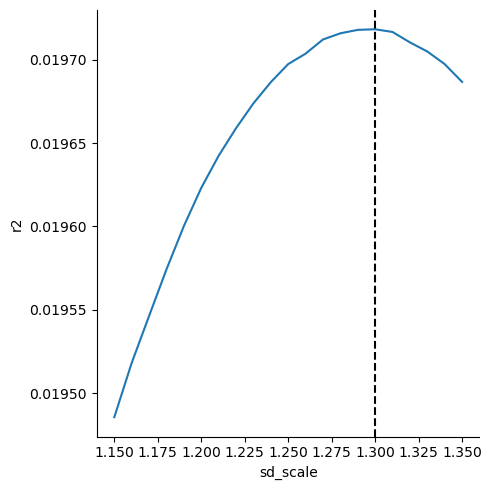

In [98]:
import matplotlib.pyplot as plt
sns.relplot(data=df.xs(True, level='fit_responses')[('r2', 'nan')].groupby(level=['subject', 'sd_scale']).mean().to_frame('r2').reset_index(), x='sd_scale', y='r2', kind='line',
            errorbar=None,)

plt.axvline(1.3, c='k', ls='--')

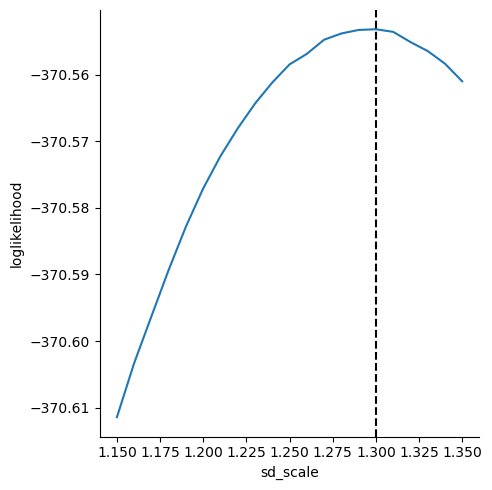

In [104]:
import matplotlib.pyplot as plt
sns.relplot(data=df.xs(True, level='fit_responses')[('loglikelihood', 'nan')].groupby(level=['subject', 'sd_scale']).mean().to_frame('loglikelihood').reset_index(), x='sd_scale', y='loglikelihood', kind='line',
            errorbar=None,)

plt.axvline(1.3, c='k', ls='--')

In [109]:
df.xs(True, level='fit_responses')[('loglikelihood', 'nan')].groupby('sd_scale').mean().sort_values()

sd_scale
1.15   -372.099619
1.16   -372.091343
1.17   -372.084124
1.18   -372.077163
1.19   -372.070472
1.20   -372.064555
1.21   -372.059508
1.22   -372.055036
1.23   -372.051115
1.24   -372.047751
1.35   -372.045579
1.25   -372.044872
1.34   -372.043244
1.26   -372.043029
1.33   -372.041521
1.27   -372.040652
1.32   -372.040258
1.28   -372.039573
1.31   -372.038944
1.29   -372.038898
1.30   -372.038724
Name: (loglikelihood, nan), dtype: float64